#**1st HOMEWORK - Application flow identification**              
The goal is to build a multi-class classifier able to distinguish traffic flows generated by three different applications: Skype, Dropbox, Google.

## Input data
Before running the notebook, upload `22_apps_flow_features.csv` in the Colab Files panel.

## Workflow (logical steps)

1. **Setup**: install/import libraries and define constants/functions  
2. **Dataset creation**:: creating a subset of the original dataset by selecting only the samples belonging to the three target applications.
3. **Data visualization**: plot and compare the distributions of relevant traffic features
4. **Dataset loading**: load the created dataset, separate features and labels, encode the target classes, and split the data into training and test sets
5. **Hyperparameters optimization and model training**: train the models and tune their hyperparameters  
6. **Testing and performance evaluation**: test the trained models on unseen data and evaluate their performance using specific metrics.





In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [ ]:
# =========================
# IMPORTS
# =========================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import sklearn.metrics as mt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

In [ ]:
# =========================
# CONSTANTS
# =========================

#application names
apps = ['DROPBOX', 'GOOGLE', 'SKYPE']

In [ ]:
# =========================
# FUNCTIONS
# =========================

def create_dataset(filename, app_names):
# Inputs: - filename: name of the full data file to be read
#         - app_names: list with names of the apps traffic flows which we want to distinguish
# Outputs: - features file (.csv) with the dataset
#           The generated file should be put in a subfolder named "Features"

    # e.g., Min.Packet.Length = min(Fwd.Packet.Length.Min, Bwd.Packet.Length.Min)
    selected_features = [
       'Fwd.Packet.Length.Max', 'Fwd.Packet.Length.Min', 'Fwd.Packet.Length.Mean',
       'Bwd.Packet.Length.Max', 'Bwd.Packet.Length.Min', 'Bwd.Packet.Length.Mean',
       'Flow.Bytes.s',  'Flow.Packets.s',
       'Flow.IAT.Mean', 'Flow.IAT.Max', 'Flow.IAT.Min',
       'Fwd.IAT.Mean',  'Fwd.IAT.Max',  'Fwd.IAT.Min',
       'Bwd.IAT.Mean',  'Bwd.IAT.Max',  'Bwd.IAT.Min',
       'Min.Packet.Length', 'Max.Packet.Length', 'Packet.Length.Mean']

    print('Creating dataset with flows of apps {} and {} and {} from file {}'.format(app_names[0], app_names[1], app_names[2], filename))

    feature_folder = 'Features'
    if not os.path.exists(feature_folder):
        os.makedirs(feature_folder)

    # Use df as name for the pandas dataframe where to put the dataset
    df = pd.read_csv(filename, delimiter = ',')

    # select flows (row-wise) for the given apps ...
    df = df[(df['ProtocolName'] == app_names[0]) | (df['ProtocolName'] == app_names[1]) | (df['ProtocolName'] == app_names[2])]

    # store list of labels, we save it in a numpy format because all the ML pipeline works better with
    # objects like array/matrixes
    label_vector = df['ProtocolName'].to_numpy()

    # ... and use only the necessary features (column-wise filter)
    df = df[selected_features]

    # append column 'Label'
    df['Label'] = label_vector

    # example demonstrating that Min.Packet.Length = min(Fwd.Packet.Length.Min, Bwd.Packet.Length.Min)
    #print(df.iloc[0])

    # filter out flows with unreasonable values (doesn't seem to happen)
    # the if condition is used just for knowing what are the features, if any, with
    # negative values, and also it is used to check if the filter actually remove smtg
    # so in practice we could have written direclty the filter out line
    for feature in selected_features:
        # how many rows have negative value for that feature, if the number is different
        # from 0 it means that at least we have 1 feature with negative values in some flows
        if df[df[feature] < 0].shape[0] != 0:
            print('Feature {} has negative values in some flows').format(feature)
            df = df[df[feature] >= 0]

    # check if there are NaN, inf (doesn't seem to happen)
    df.replace([np.inf, -np.inf], np.nan, inplace=True) #there is dropna but no dropinf

    if pd.isnull(df).any(axis = None):
        print('There are NaN or inf values')
        # inplace = True modifies the panda object directly, without creating another one
        # from scratch
        df.dropna(inplace=True)

    # check if there are duplicate rows
    if df.duplicated().any(axis = None):
        print('There are duplicated rows')
        df.drop_duplicates(inplace=True)

    df.to_csv(feature_folder + '/apps_flow_dataset_' + app_names[0] + '_' + app_names[1] +  '_' + app_names[2] + '.csv', index=False)




def plot_feature_distribution(app_names):
# Input: - app_names - names of the apps traffic flows of which we want to distinguish
# Output: - plots of the distribution of each feature for 2 apps in the dataset;
#           figures should be also saved into a subfolder ("Figures")

    print('Plotting feature distribution for apps {} and {} and {}'.format(app_names[0], app_names[1], app_names[2]))
    fig_folder = 'Figures'
    if not os.path.exists(fig_folder):
        os.makedirs(fig_folder)

    df = pd.read_csv('Features/apps_flow_dataset_{}_{}_{}.csv'.format(app_names[0], app_names[1],app_names[2]))

    plt.figure(figsize=(15, 60))
    for i, column_name in enumerate(df.columns):
      # we don't plot Label cause it is not a numeric feature, but the class we want to predict at the end
        if column_name != 'Label':
            ax = plt.subplot(df.columns.size, 1, i + 1)
            # group by data for each Label. Then for each group, take the current feature
            # and draw an histogram in the same axis
            # alpha = 0.5 makes the histograms semi-transparent, so you can see where the distributions overlaps
            df.groupby('Label')[column_name].plot(kind = 'hist', alpha = 0.5, ax=ax)
            plt.title('Distribution of feature {} for classes {} and {} and {}'.format(column_name, app_names[0], app_names[1], app_names[2]))
            plt.xlabel(column_name)
            plt.legend(loc='best')
            plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)


    plt.savefig(fig_folder + '/features_' + app_names[0] + '_' + app_names[1] + '_' + app_names[2] + '.png', bbox_inches='tight')
    #plt.close()


def load_dataset(app_names):
#Inputs: - app_names: names of the apps traffic flows of which we want to distinguish
#Outputs: - X: matrix (numpy.ndarray) of features retrieved from filename
#         - y: column (numpy.ndarray) of labels retrieved from filename


    feature_df = pd.read_csv('Features/apps_flow_dataset_{}_{}_{}.csv'.format(app_names[0], app_names[1], app_names[2])) #support dataframe

    # We assign 0 to DROPBOX, 1 to GOOGLE and 2 to SKYPE
    feature_df['Label'] = feature_df['Label'].apply(lambda x: 0 if x == app_names[0] else (1 if x == app_names[1] else 2))
    X = feature_df.drop(columns=['Label']).to_numpy()
    y = feature_df['Label'].to_numpy()

    return X, y
def train_classifier_logistic(X_train, y_train, resfilelogistic):
#Inputs: - X_train: training set (features)
#        - y_train: training set (ground truth labels)
#        - resfilelogistic: full name (with path) of the results file where to put output of the training/optimization process
#This function should:
#         * Perform logistic regression hyperparameters optimization via 5-fold crossvalidation
#         * Print hyperparameters obtained with crossvalidation in resfilelogistic
#         * Retrain a logistic regression model with best hyperparameters using the entire training set (X_train, y_train)
#         * Print training results (best accuracy and training duration) in resfilelogistic
#         * Return the trained model
#
#Outputs: - updated resfilelogistic with:
#                   1) best hyperparameters obtained with crossvalidation
#                   2) best accuracy obtained during crossvalidation (for the best hyperparameters)
#                   3) duration of training over the entire training set (X_train, y_train)
#         - bestlogisticRegr: model to be returned by the function
#         - best_params: dictionary with best hyperparameters obtained with crossvalidation


    # crossvalidation
    n_split_kfold = 5
    skf = KFold(n_splits=n_split_kfold, shuffle=True, random_state=42)

    best_params = {'regularization': 0, 'max_iter': 0, 'score': 0}
    C_reg_range = [1, 10, 100, 1000]
    maxit_range = [1000, 5000, 10000]
    scoreplot = np.zeros([len(C_reg_range),len(maxit_range)])

    t0 = time.time()
    for i, C_reg in enumerate(C_reg_range): #loop over regularization parameter

        for j, maxit in enumerate(maxit_range): #loop over maximum iterations

            print(f'Testing hyperparameters: regularization: {C_reg}, max_iter: {maxit}')

            score = 0
            for train_index, test_index in skf.split(X_train, y_train):

                X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
                y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

                # Instantiate
                logisticRegr = LogisticRegression(C=C_reg, max_iter=maxit, random_state=42)

                # Train
                logisticRegr.fit(X_train_fold, y_train_fold)

                # Calculate score and cumulate with scores on previous folds
                score += logisticRegr.score(X_test_fold, y_test_fold)

            score = score / n_split_kfold
            #print('Score: '+str(score))
            scoreplot[i,j] = score

            if score > best_params['score']:
                best_params['score'] = score
                best_params['regularization'] = C_reg
                best_params['max_iter'] = maxit
                #print('New best hyperparameters!!')

    t1 = time.time()
    crossval_time = round(t1 - t0, 3)
    print('Crossval time [s]: ' + str(crossval_time))
    print('Best hyperparams during crossval: ' + str(best_params))

    print(scoreplot)

    for p in list(range(scoreplot.shape[1])):
        plt.plot(C_reg_range,scoreplot[:, p], label=f'maxiter={maxit_range[p]}')

    plt.xlabel("Regularization parameter 'C'")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

    training_time = 0 #F: here you will store final training time
    finalscore = 0 #F: here you will store final accuracy

    #now retrain with best_params and using the entire training set
    #this part should produce the final model bestlogisticRegr to be returned at the end (together with best_params)

    bestlogisticRegr = LogisticRegression(C = best_params['regularization'], max_iter = best_params['max_iter'], random_state = 42)
    t0 = time.time()
    bestlogisticRegr.fit(X_train, y_train)
    t1 = time.time()
    training_time = round(t1 - t0,3)
    finalscore = bestlogisticRegr.score(X_train, y_train)
    print('Score of the final model: ' + str(finalscore))
    print('Training time [s]: ' + str(training_time))


    with open(resfilelogistic, 'w') as result_file:
        result_file.write('*** LOGISTIC REGRESSION ***\n')
        result_file.write('*** Crossvalidation results ***\n')
        result_file.write('Best C: {}\n'.format(best_params['regularization']))
        result_file.write('Best number of iterations: {}\n'.format(best_params['max_iter']))
        result_file.write('Best crossvalidation accuracy: {}\n\n'.format(best_params['score']))

        result_file.write('*** Best model results (retrained with entire training set) ***\n')
        result_file.write('Accuracy: {}\n'.format(finalscore))
        result_file.write('Training duration [s]: {}\n'.format(training_time))


    return bestlogisticRegr, best_params



def train_classifier_XGB(X_train, y_train, resfileXGB):
#Inputs: - X_train: training set (features)
#        - y_train: training set (ground truth labels)
#        - resfileXGB: full name (with path) of the results file where to put output of the training/optimization process
#This function should:
#         * Perform XGB hyperparameters optimization via 5-fold crossvalidation.
#         * Use the following XGB hyperparameters with ranges specified below: n_estimators, max_depth, subsample
#         * Print best hyperparameters obtained with crossvalidation in resfileXGB
#         * Retrain a XGB model with best hyperparameters using the entire training set (X_train, y_train)
#         * Print training results (best accuracy and training duration) in resfileXGB
#         * Return the trained model
#
#Outputs: - updated resfileXGB with:
#                   1) best hyperparameters obtained with crossvalidation
#                   2) best accuracy obtained during crossvalidation (for the best hyperparameters)
#                   3) duration of training over the entire training set (X_train, y_train)
#         - bestXGB: model to be returned by the function
#         - best_params: dictionary with best hyperparameters obtained with crossvalidation

    best_params = {'n_estimators': 0, 'max_depth': 0, 'subsample': 0, 'score': 0}
    num_estimators_range = [25, 50, 100]
    max_depth_range = [5, 20, 50]
    subsample_range = [0.7, 0.9, 1]

    # crossvalidation
    n_split_kfold = 5
    skf = KFold(n_splits=n_split_kfold, shuffle=True, random_state=42)

    scoreplot = np.zeros([len(num_estimators_range), len(max_depth_range), len(subsample_range)])

    t0 = time.time()
    for i, n_est in enumerate(num_estimators_range): #loop over num_estimators
        for j, max_dep in enumerate(max_depth_range): #loop over max_depth
            for k, subsamp in enumerate(subsample_range): #loop subsample

                print(f'Testing hyperparameters: n_estimators: {n_est}, max_depth: {max_dep}, subsample: {subsamp}')
                score = 0
                for train_index, test_index in skf.split(X_train, y_train):
                    X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
                    y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

                    xgb = XGBClassifier(verbosity = 0, objective = 'multi:softmax', num_class = 3, eval_metric=['merror', 'mlogloss'],
                                          n_estimators = n_est, max_depth = max_dep, subsample = subsamp)

                    xgb.fit(X_train_fold, y_train_fold)
                    score += xgb.score(X_test_fold, y_test_fold)

                score = score / n_split_kfold
                #print('Score: '+str(score))
                scoreplot[i, j, k] = score

                if score > best_params['score']:
                    best_params['score'] = score
                    best_params['n_estimators'] = n_est
                    best_params['max_depth'] = max_dep
                    best_params['subsample'] = subsamp
                    #print('New best hyperparameters!!')
    t1 = time.time()
    crossval_time = round(t1 - t0,3)
    print('Crossval time [s]: ' + str(crossval_time))
    print('Best hyperparams: ' + str(best_params))

    print(scoreplot)
    #print(scoreplot.shape)

    for p in list(range(scoreplot.shape[0])):
        for q in list(range(scoreplot.shape[1])):
            #print('p,q: ' + str(p)+str(q))
            plt.plot(subsample_range, scoreplot[p,q,:], label=f'n_est={num_estimators_range[p]} - max_dep={max_depth_range[q]} ')

    plt.xlabel("Subsample")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

    #now retrain with best_params and using the entire training set
    bestxgb = XGBClassifier(verbosity = 0, objective = 'multi:softmax', num_class = 3, eval_metric=['merror', 'mlogloss'],
                                          n_estimators = best_params['n_estimators'],
                                          max_depth = best_params['max_depth'],
                                          subsample = best_params['subsample'])

    t0 = time.time()
    bestxgb.fit(X_train, y_train)
    t1 = time.time()
    training_time = round(t1-t0,3)
    finalscore = bestxgb.score(X_train, y_train)
    print('Score of the final model: ' + str(finalscore))
    print(f'Best n_estimators: {best_params["n_estimators"]}.')
    print(f'Best max_depth: {best_params["max_depth"]}.')
    print(f'Best subsample: {best_params["subsample"]}')
    print('Training time [s]: ' + str(training_time))

    with open(resfileXGB, 'w') as result_file:
        result_file.write('*** XGB ***\n')
        result_file.write('*** Crossvalidation results ***\n')
        result_file.write('Best n_estimators: {}\n'.format(best_params['n_estimators']))
        result_file.write('Best max_depth: {}\n'.format(best_params['max_depth']))
        result_file.write('Best subsample: {}\n'.format(best_params['subsample']))
        result_file.write('Best crossvalidation accuracy: {}\n\n'.format(best_params['score']))

        result_file.write('*** Best model results (retrained with entire training set) ***\n')
        result_file.write('Accuracy: {}\n'.format(finalscore))
        result_file.write('Training duration [s]: {}\n'.format(training_time))

    return bestxgb, best_params



def performance_eval(y_true, y_pred, lab, l_names, resfile):
#Inputs: - y_true: ground-truth labels
#        - y_pred: predicted labels
#        - lab: list of labels (integers) as used during training phase
#        - l_names: list of labels (categories) corresponding to integer labels "lab";
#                   can be customized, it's only used for results plotting
#        - resfile: full name (with path) of the results file where to put performance metrics
#This function should:
#         * Compute Accuracy, Precision (global-weighted and per class), Recall (global-weighted and per class), F1-score (global-weighted and per class)
#         * Write them in result .txt file (resfile passed in input)
#         * Compute confusion matrix (cm) and save it in the same result .txt file (resfile)
#         * Return Accuracy, overall Precision, overall Recall, overall F1-score
#         * Plot of the cm is already given in the code (you need to call the confusion matrix objects as cm and cm_norm)
#Outputs: - updated resfileXGB with:
#                              1) Accuracy, Precision (global-weighted and per class), Recall (global-weighted and per class), F1-score (global-weighted and per class)
#                              2) Confusion matrix (cm) and confusion matrix normalized wrt true labels (cm_norm)
#         - return accuracy, global_precision, global_recall, global_f1score (use these variable names!)

    #Compute metrics and print/write them
    accuracy = mt.accuracy_score(y_true, y_pred)
    precision = mt.precision_score(y_true, y_pred, labels=lab, average=None) #F: average=None gives per-class results
    # average='weighted': computes the metric for each class independently, then takes
    # a weighted average based on the number of samples per class. This is more
    # representative than a simple average when classes are imbalanced (e.g., 900 cats
    # and 100 dogs), as larger classes contribute more to the final score.
    #
    # average=None: returns one score per class as an array (e.g., [0.8, 0.75, 0.9]),
    # useful to inspect how well the model performs on each individual class.
    global_precision = mt.precision_score(y_true, y_pred, labels=lab, average='weighted')
    recall = mt.recall_score(y_true, y_pred, labels=lab, average=None)
    global_recall = mt.recall_score(y_true, y_pred, labels=lab, average='weighted')
    f1score = mt.f1_score(y_true, y_pred, labels=lab, average=None)
    global_f1score = mt.f1_score(y_true, y_pred, labels=lab, average='weighted')

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] #F: normalized wrt true labels (axis=1 sums the elements of one row and sums them; this is done for all the rows independently)

    with open(resfile, 'w') as result_file:
        result_file.write('Results for the TEST SET\n')
        result_file.write('Accuracy: {}\n'.format(accuracy))
        result_file.write('Precision per class: {}\n'.format(precision))
        result_file.write('Global Precision: {}\n'.format(global_precision))
        result_file.write('Recall per class: {}\n'.format(recall))
        result_file.write('Global Recall: {}\n'.format(global_recall))
        result_file.write('F1-score: {}\n'.format(f1score))
        result_file.write('Global F1-score: {}\n'.format(global_f1score))

        result_file.write('\nConfusion matrix, without normalization\n')
        np.savetxt(result_file, cm, fmt = '%.2f')

        result_file.write('\nNormalized confusion matrix\n')
        #np.savetxt(result_file, cm_norm, fmt = '%.2f')
        result_file.write(str(cm_norm))



#F: in the following, we plot the confusion matrices (absolute and normalized one)
# ------------------------------- absolute -------------------------------
        title = 'Confusion matrix'
        fig, ax = plt.subplots()
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        # We want to show all ticks...
        ax.set(xticks=np.arange(cm.shape[1]),
               yticks=np.arange(cm.shape[0]),
               # ... and label them with the respective list entries
               #xticklabels=lab, yticklabels=lab,
               xticklabels=l_names, yticklabels=l_names,
               title=title,
               ylabel='True label',
               xlabel='Predicted label')

        # Rotate the tick labels and set their alignment.
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Loop over data dimensions (#F: i.e., cells in the confusion matrix) and create text annotations.
        fmt = 'd'
        thresh = cm.max() / 2.
        for w in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, w, format(cm[w, j], fmt),
                        ha="center", va="center",
                        color="white" if cm[w, j] > thresh else "black")
        fig.tight_layout()
        fig.savefig(resfile.replace('.txt','_conf_matrix.png'))
        plt.show()
# ------------------------------- normalized -------------------------------
        title_norm = 'Normalized confusion matrix'
        fig_n, ax_n = plt.subplots()
        im = ax_n.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
        ax_n.figure.colorbar(im, ax=ax_n)
        # We want to show all ticks...
        ax_n.set(xticks=np.arange(cm_norm.shape[1]),
               yticks=np.arange(cm_norm.shape[0]),
               # ... and label them with the respective list entries
               #xticklabels=lab, yticklabels=lab,
               xticklabels=l_names, yticklabels=l_names,
               title=title_norm,
               ylabel='True label',
               xlabel='Predicted label')

        # Rotate the tick labels and set their alignment.
        plt.setp(ax_n.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Loop over data dimensions (#F: i.e., cells in the confusion matrix) and create text annotations.
        fmt = '.2f'
        thresh = cm_norm.max() / 2.
        for w in range(cm_norm.shape[0]):
            for j in range(cm_norm.shape[1]):
                ax_n.text(j, w, format(cm_norm[w, j], fmt),
                        ha="center", va="center",
                        color="white" if cm_norm[w, j] > thresh else "black")
        fig_n.tight_layout()
        fig_n.savefig(resfile.replace('.txt','_conf_matrix_normalized.png'))
        plt.show()

# Now we return the global metrics (Accuracy, Precision, Recall, F1-score) calculated above

    return accuracy, global_precision, global_recall, global_f1score


In [ ]:
create_dataset('22_apps_flow_features.csv', apps)

Creating dataset with flows of apps DROPBOX and GOOGLE and SKYPE from file 22_apps_flow_features.csv
There are duplicated rows


Plotting feature distribution for apps DROPBOX and GOOGLE and SKYPE


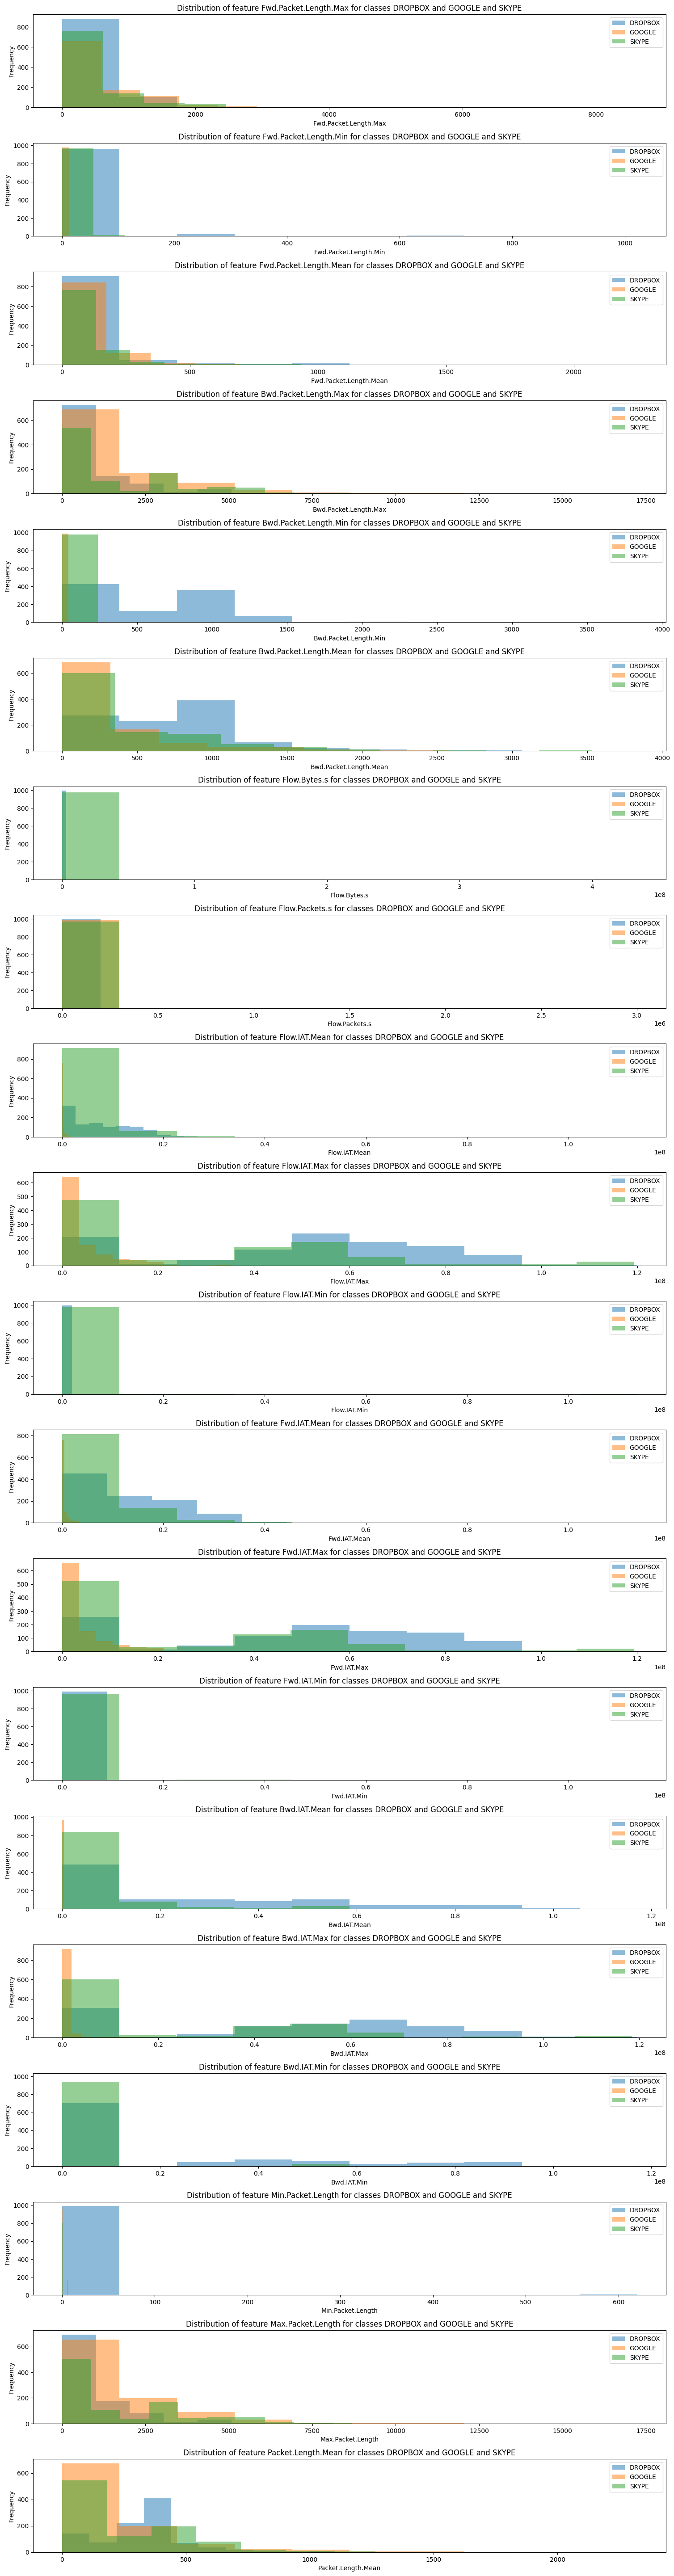

In [ ]:
plot_feature_distribution(apps)

##Comment on the obtained result

As it can be seen from the graphs, the three apps have partially overlapping feature distributions, and there is no single feature that clearly separates all the classes. If one feature had a clear distinction, a simple treshold-based rule would be enough, without needing a ML algorithm. Instead, since the classes overlap, the classifier needs to combine multiple features to learn more complex decision boundaries.

In [ ]:
# ===========================
# LOAD DATASET
# ===========================
X, y = load_dataset(apps)

print(X.shape)
print(y.shape)

(2970, 20)
(2970,)


In [ ]:
# ======================================
# TRAIN-TEST SPLIT + CLASS DISTRIBUTION
# ======================================

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(X.shape)
print(y.shape)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print()

# class distribution in y, y_train, y_test
for cls in np.unique(y):
    print(f'# samples of class {cls} in y       = {np.count_nonzero(y == cls)}')
    print(f'# samples of class {cls} in y_train = {np.count_nonzero(y_train == cls)}')
    print(f'# samples of class {cls} in y_test  = {np.count_nonzero(y_test == cls)}')
    print()


(2970, 20)
(2970,)
(2376, 20)
(2376,)
(594, 20)
(594,)
# samples of class 0 in y       = 998
# samples of class 0 in y_train = 798
# samples of class 0 in y_test  = 200

# samples of class 1 in y       = 991
# samples of class 1 in y_train = 793
# samples of class 1 in y_test  = 198

# samples of class 2 in y       = 981
# samples of class 2 in y_train = 785
# samples of class 2 in y_test  = 196



Testing hyperparameters: regularization: 1, max_iter: 1000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Testing hyperparameters: regularization: 1, max_iter: 5000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Testing hyperparameters: regularization: 1, max_iter: 10000


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Testing hyperparameters: regularization: 1000, max_iter: 10000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Crossval time [s]: 566.412
Best hyperparams during crossval: {'regularization': 1, 'max_iter': 10000, 'score': 0.6077408226448474}
[[0.46885537 0.58712163 0.60774082]
 [0.45707121 0.57237417 0.59720301]
 [0.45792039 0.57197346 0.60563379]
 [0.4667448  0.55806457 0.59805484]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


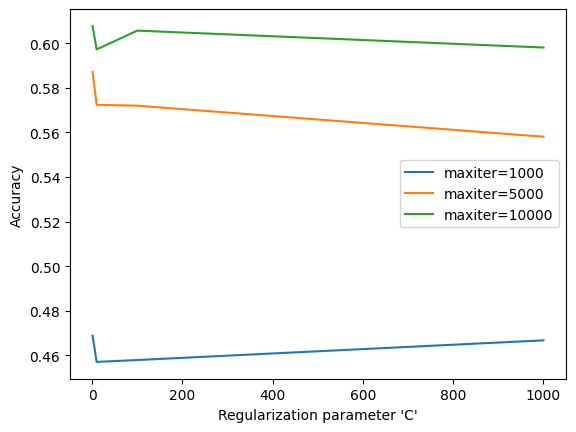

Score of the final model: 0.61489898989899
Training time [s]: 13.179


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
res_folder = 'Results'
if not os.path.exists(res_folder):
    os.makedirs(res_folder)
resf = res_folder + '/testlogregr_results.txt'
logreg, best_params_logreg = train_classifier_logistic(X_train, y_train, resf)

(2376, 20)
(2376,)
(594, 20)
(594,)
Testing hyperparameters: regularization: 1, max_iter: 1000
Testing hyperparameters: regularization: 1, max_iter: 5000
Testing hyperparameters: regularization: 1, max_iter: 10000
Testing hyperparameters: regularization: 10, max_iter: 1000
Testing hyperparameters: regularization: 10, max_iter: 5000
Testing hyperparameters: regularization: 10, max_iter: 10000
Testing hyperparameters: regularization: 100, max_iter: 1000
Testing hyperparameters: regularization: 100, max_iter: 5000
Testing hyperparameters: regularization: 100, max_iter: 10000
Testing hyperparameters: regularization: 1000, max_iter: 1000
Testing hyperparameters: regularization: 1000, max_iter: 5000
Testing hyperparameters: regularization: 1000, max_iter: 10000
Crossval time [s]: 16.665
Best hyperparams during crossval: {'regularization': 1000, 'max_iter': 1000, 'score': 0.7512666961521451}
[[0.72853958 0.72853958 0.72853958]
 [0.7428483  0.7428483  0.7428483 ]
 [0.74747988 0.74747988 0.7474

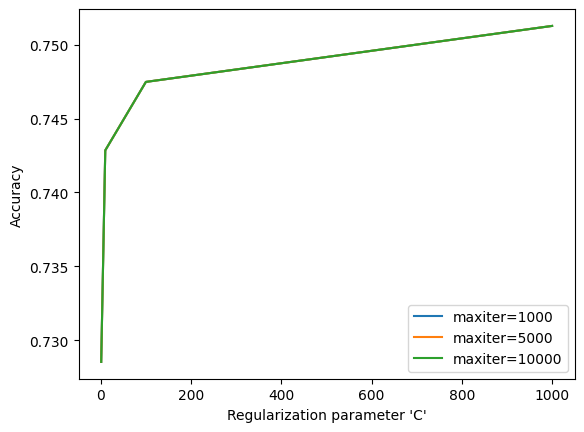

Score of the final model: 0.757996632996633
Training time [s]: 0.487


In [ ]:
# ================================
# STANDARDIZATION
# ================================

# Raw features may have very different scales (e.g., one feature in range [0,1]
# and another in range [0,10000]), which causes the logistic regression solver
# (lbfgs) to converge slowly or not at all (ConvergenceWarning).
#
# StandardScaler fixes this by transforming each feature to have mean=0 and
# standard deviation=1, so all features are on the same scale.
#
# Important: the scaler is fitted ONLY on X_train (to learn mean and std),
# then the same transformation is applied to X_test.
# Fitting on X_test separately would cause data leakage (the model would
# indirectly "see" test data during training, making results unreliable)

scaler = StandardScaler()
# with the function fit_transform the model learn the statistics
# x_scaled = (x - media) / std formula used
X_train_std = scaler.fit_transform(X_train)
# instead with transform it uses the same statistics of the training
X_test_std = scaler.transform(X_test)

print(X_train_std.shape)
print(y_train.shape)
print(X_test_std.shape)
print(y_test.shape)



###############################################
res_folder = 'Results'
if not os.path.exists(res_folder):
    os.makedirs(res_folder)
resf=res_folder + '/testlogregr_results_STD.txt'
logreg_std, best_params_logreg_std = train_classifier_logistic(X_train_std, y_train, resf)

Testing hyperparameters: n_estimators: 25, max_depth: 5, subsample: 0.7
Testing hyperparameters: n_estimators: 25, max_depth: 5, subsample: 0.9
Testing hyperparameters: n_estimators: 25, max_depth: 5, subsample: 1
Testing hyperparameters: n_estimators: 25, max_depth: 20, subsample: 0.7
Testing hyperparameters: n_estimators: 25, max_depth: 20, subsample: 0.9
Testing hyperparameters: n_estimators: 25, max_depth: 20, subsample: 1
Testing hyperparameters: n_estimators: 25, max_depth: 50, subsample: 0.7
Testing hyperparameters: n_estimators: 25, max_depth: 50, subsample: 0.9
Testing hyperparameters: n_estimators: 25, max_depth: 50, subsample: 1
Testing hyperparameters: n_estimators: 50, max_depth: 5, subsample: 0.7
Testing hyperparameters: n_estimators: 50, max_depth: 5, subsample: 0.9
Testing hyperparameters: n_estimators: 50, max_depth: 5, subsample: 1
Testing hyperparameters: n_estimators: 50, max_depth: 20, subsample: 0.7
Testing hyperparameters: n_estimators: 50, max_depth: 20, subsamp

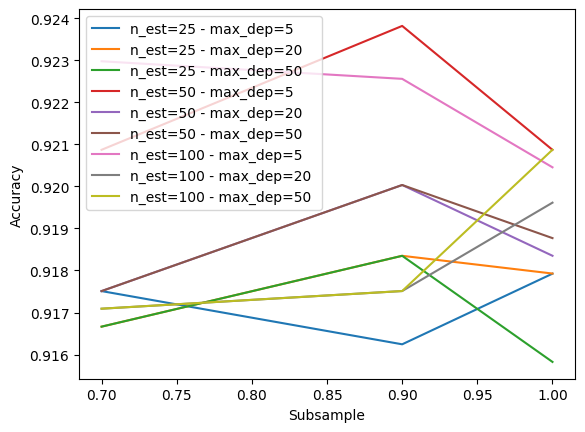

Score of the final model: 0.9907407407407407
Best n_estimators: 50.
Best max_depth: 5.
Best subsample: 0.9
Training time [s]: 0.303


In [ ]:
res_folder = 'Results'
if not os.path.exists(res_folder):
    os.makedirs(res_folder)
resf=res_folder + '/testXGB_results.txt'
XGB, best_params_XGB = train_classifier_XGB(X_train, y_train, resf)

--------------------
Shape logreg : (594,)
Shape XGB : (594,)
--------------------
************** LOGISTIC REGRESSION **************


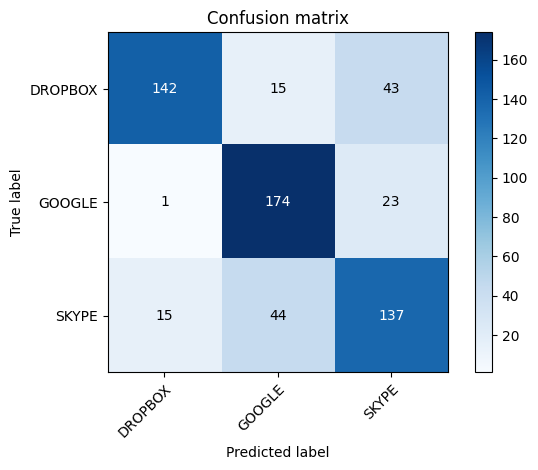

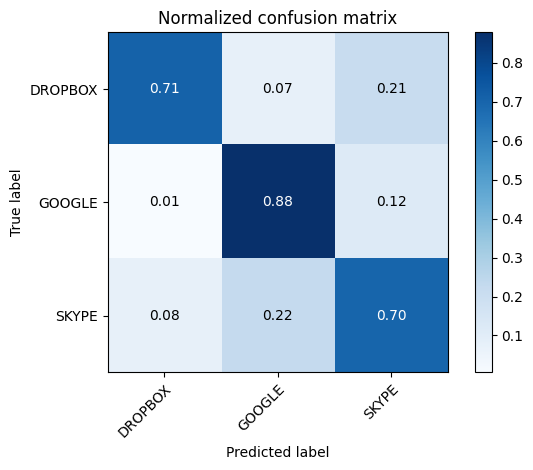

Logistic regression metrics (accuracy, global precision, global recall, global f1score): (0.7626262626262627, 0.7742177751788039, 0.7626262626262627, 0.7628380112975313)
**************************************************


************** XGB **************


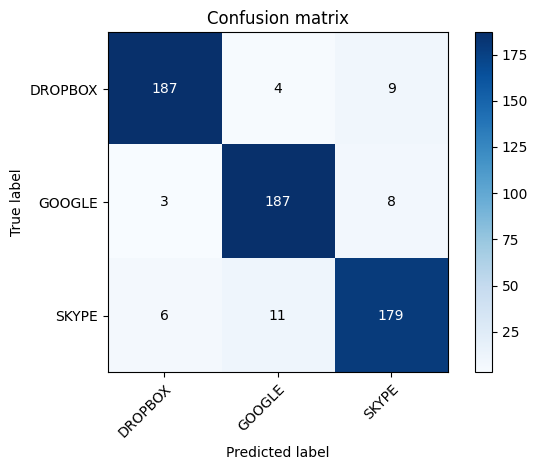

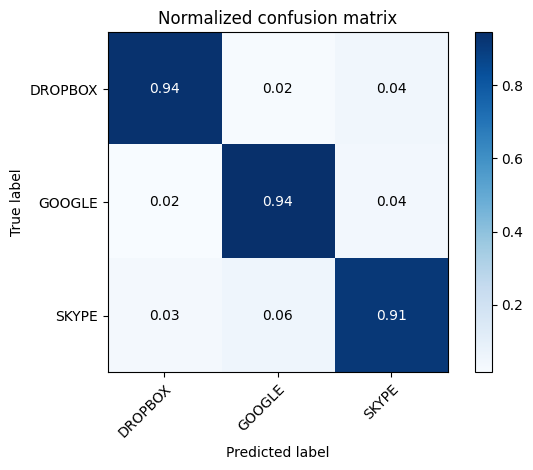

XGB metrics (accuracy, global precision, global recall, global f1score): (0.930976430976431, 0.9311672663865026, 0.930976430976431, 0.9310082304526749)


In [ ]:
# ===============================
# PREDICTIONS
# ===============================


y_pred_logreg = logreg_std.predict(X_test_std)
# XGBoost doesn't need the standardization, because it is based on decision trees which are insensitive of features scale
y_pred_XGB = XGB.predict(X_test)

print('--------------------')
print(f'Shape logreg : {y_pred_logreg.shape}')
print(f'Shape XGB : {y_pred_XGB.shape}')
print('--------------------')

#file names to pass as input to performance_eval()
restestfilelogreg = res_folder + '/logreg_test_results.txt'
restestfileXGB = res_folder + '/XGB_test_results.txt'

lbl = [0, 1,2]
label_names=apps #label names to use as inputs to performance_eval()

print('************** LOGISTIC REGRESSION **************')
logreg_metrics = performance_eval(y_test, y_pred_logreg, lbl, label_names, restestfilelogreg)
print('Logistic regression metrics (accuracy, global precision, global recall, global f1score): ' +str(logreg_metrics))
print('**************************************************\n\n')

print('************** XGB **************')
XGB_metrics = performance_eval(y_test, y_pred_XGB, lbl, label_names, restestfileXGB)
print('XGB metrics (accuracy, global precision, global recall, global f1score): ' +str(XGB_metrics))

##Comment on the obtained result

As shown in the Confusion Matrix, Logistic Regression obtains a decent overall performance, with an accuracy of 76%. GOOGLE is the easiest class to recognize with an 88% classified samples, whereas DROPBOX and SKYPE are more often confused with each other and with GOOGLE.

On the other hand, XGBoost performs way better because it can model non-linear relationships between features, producing a better confusion matrix with fewer misclassifcations.

#

--------------------
Original shape: (2970, 20)
PCA-transformed shape: (2970, 2)
--------------------


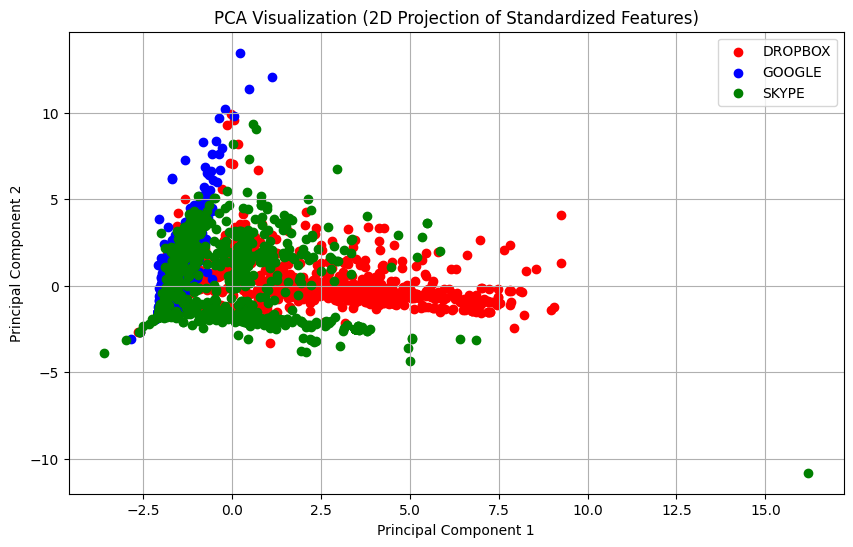

In [ ]:
# ======================================
# PCA 2D VISUALIZATION
# ======================================

# Standardize the feature matrix before PCA
X_scaled = scaler.fit_transform(X)

# Reduce the standardized dataset from the original feature space to 2 PCA components
pca_model = PCA(n_components=2)
X_pca = pca_model.fit_transform(X_scaled)

print('--------------------')
print("Original shape:", X.shape)
print("PCA-transformed shape:", X_pca.shape)
print('--------------------')

# Create the 2D plot
plt.figure(figsize=(10, 6))

plot_colors = ['red', 'blue', 'green']
legend_items = []

# Plot one scatter plot for each application label
for i, class_id in enumerate(np.unique(y)):
    points = X_pca[y == class_id]

    plot = plt.scatter(
        points[:, 0],
        points[:, 1],
        c=plot_colors[i % len(plot_colors)],
        label=apps[class_id]
    )

    legend_items.append(plot)

plt.legend(handles=legend_items, loc='best')
plt.title('PCA Visualization (2D Projection of Standardized Features)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

##Comment on the obtained result

As shown in the graph, the three classes are not clearly separated and no linear boundary can suitably divide them. SKYPE overlaps significantly with both GOOGLE and DROPBOX in the central region, making it the hardest class to classify. DROPBOX is partially distinguishable due to its spread along the first principal component. This non-linear structure explains why XGBoost performs better  than Logistic Regression: being a tree-based model, it can capture complex, non-linear decision boundaries that a linear classifier cannot.